# Penerapan Transfer Learning VGG16 untuk Klasifikasi Jenis Hewan Reptil

Notebook ini mendemonstrasikan penggunaan **Transfer Learning** dengan arsitektur **VGG16** (pre-trained pada ImageNet) untuk melakukan klasifikasi citra jenis hewan reptil (misalnya: ular, kadal, buaya, kura-kura, dsb).

## Struktur Dataset yang Diharapkan
Notebook ini mengasumsikan dataset citra disusun dalam struktur folder sebagai berikut:

```
dataset/
├── train/
│   ├── ular/
│   ├── kadal/
│   ├── buaya/
│   └── kura_kura/
├── val/
│   ├── ular/
│   ├── kadal/
│   ├── buaya/
│   └── kura_kura/
└── test/
    ├── ular/
    ├── kadal/
    ├── buaya/
    └── kura_kura/
```

Silakan sesuaikan `DATASET_DIR` pada sel konfigurasi dengan lokasi dataset Anda. Jika belum memiliki folder `val`/`test` terpisah, notebook ini juga menyediakan opsi split otomatis menggunakan `validation_split`.

## Tahapan
1. Import library
2. Konfigurasi & load dataset
3. Augmentasi data
4. Membangun model VGG16 (transfer learning)
5. Compile & training (fase 1: freeze base model)
6. Fine-tuning (fase 2: unfreeze sebagian layer)
7. Evaluasi model (akurasi, confusion matrix, classification report)
8. Visualisasi hasil prediksi
9. Menyimpan model


## 1. Import Library

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.21.0
GPU tersedia: []


## 2. Konfigurasi & Parameter

Ubah nilai-nilai berikut sesuai kebutuhan Anda.

In [9]:
# Path dataset (ubah sesuai lokasi dataset Anda)
DATASET_DIR = "dataset"          # folder utama dataset
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

# Parameter gambar & training
IMG_SIZE = (224, 224)     # ukuran input standar VGG16
BATCH_SIZE = 32
EPOCHS_STAGE1 = 15        # training dengan base model dibekukan (frozen)
EPOCHS_STAGE2 = 10        # fine-tuning dengan sebagian layer VGG16 dibuka
LEARNING_RATE_STAGE1 = 1e-3
LEARNING_RATE_STAGE2 = 1e-5

SEED = 42


## 3. Persiapan Data (Augmentasi & Generator)

Menggunakan `ImageDataGenerator` untuk augmentasi data pada data training, sedangkan data validasi dan testing hanya dilakukan preprocessing tanpa augmentasi.

In [10]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)
print("Kelas hewan reptil yang terdeteksi:", class_names)
print("Jumlah kelas:", num_classes)


Found 967 images belonging to 4 classes.


Found 967 images belonging to 4 classes.
Found 967 images belonging to 4 classes.
Kelas hewan reptil yang terdeteksi: ['buaya', 'kadal', 'kura_kura', 'ular']
Jumlah kelas: 4


### (Opsional) Visualisasi Sampel Dataset

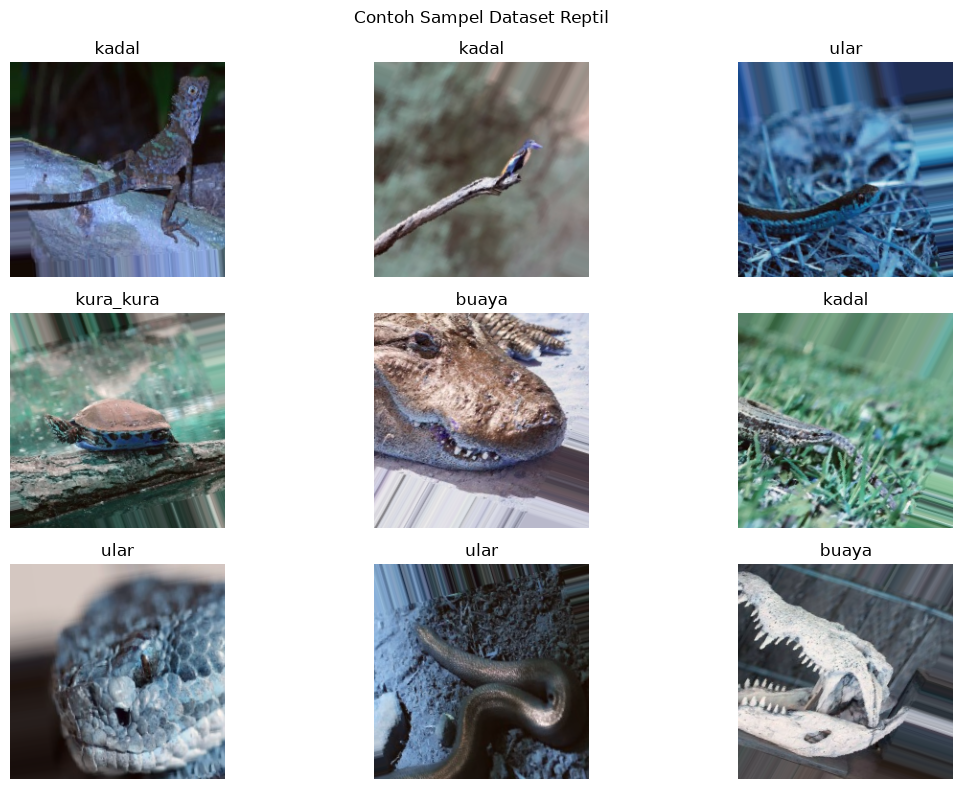

In [11]:
images, labels = next(train_generator)

plt.figure(figsize=(12, 8))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    # Karena sudah melalui preprocess_input VGG16, kita normalisasi ulang untuk visualisasi
    img_display = images[i] - images[i].min()
    img_display = img_display / (img_display.max() + 1e-8)
    plt.imshow(img_display)
    label_idx = np.argmax(labels[i])
    plt.title(class_names[label_idx])
    plt.axis("off")
plt.suptitle("Contoh Sampel Dataset Reptil")
plt.tight_layout()
plt.show()


## 4. Membangun Model VGG16 (Transfer Learning)

Base model VGG16 dimuat dengan bobot pre-trained ImageNet (`include_top=False`), kemudian ditambahkan custom classification head sesuai jumlah kelas reptil pada dataset.

In [12]:
# Load base model VGG16 tanpa fully connected layer (top)
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

# Bekukan seluruh layer base model pada tahap awal training
base_model.trainable = False

# Membangun custom head untuk klasifikasi reptil
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,89

 Total params: 14,880,452 (56.76 MB)

 Trainable params: 165,252 (645.52 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

## 5. Compile & Training (Tahap 1 — Feature Extraction)

Pada tahap ini, hanya bagian *head* (classifier) yang dilatih, sedangkan seluruh layer konvolusi VGG16 dibekukan (frozen).

In [13]:
# ==========================
# Training Configuration
# ==========================
LEARNING_RATE_STAGE1 = 1e-4
EPOCHS_STAGE1 = 10

# ==========================
# Compile Model
# ==========================
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE_STAGE1),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ==========================
# Callbacks
# ==========================
callbacks_stage1 = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        "vgg16_reptil_stage1_best.h5",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]

# ==========================
# Training Stage 1
# ==========================
history_stage1 = model.fit(
    train_generator,
    steps_per_epoch=50,          # 50 batch setiap epoch
    epochs=EPOCHS_STAGE1,        # 10 epoch
    validation_data=val_generator,
    validation_steps=len(val_generator),   # gunakan seluruh data validasi
    callbacks=callbacks_stage1,
    verbose=1
)


Epoch 1/10
31/50 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.2947 - loss: 2.0003

d:\Tugas\PA batu\VGG16\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_accuracy improved from None to 0.44571, saving model to vgg16_reptil_stage1_best.h5



Epoch 1: finished saving model to vgg16_reptil_stage1_best.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.2947 - loss: 2.0003 - val_accuracy: 0.4457 - val_loss: 1.3900 - learning_rate: 1.0000e-04
Epoch 2/10
31/50 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.3888 - loss: 1.6163
Epoch 2: val_accuracy improved from 0.44571 to 0.60910, saving model to vgg16_reptil_stage1_best.h5



Epoch 2: finished saving model to vgg16_reptil_stage1_best.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.3888 - loss: 1.6163 - val_accuracy: 0.6091 - val_loss: 0.9447 - learning_rate: 1.0000e-04
Epoch 3/10
31/50 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.4705 - loss: 1.3437
Epoch 3: val_accuracy improved from 0.60910 to 0.70734, saving model to vgg16_reptil_stage1_best.h5


...


Epoch 6: finished saving model to vgg16_reptil_stage1_best.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.5843 - loss: 1.0081 - val_accuracy: 0.8139 - val_loss: 0.5166 - learning_rate: 1.0000e-04
Epoch 7/10
31/50 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.6587 - loss: 0.8864
Epoch 7: val_accuracy improved from 0.81386 to 0.83868, saving model to vgg16_reptil_stage1_best.h5



Epoch 7: finished saving model to vgg16_reptil_stage1_best.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.6587 - loss: 0.8864 - val_accuracy: 0.8387 - val_loss: 0.4733 - learning_rate: 1.0000e-04
Epoch 8/10
31/50 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.6484 - loss: 0.8638
Epoch 8: val_accuracy improved from 0.83868 to 0.84902, saving model to vgg16_reptil_stage1_best.h5



Epoch 8: finished saving model to vgg16_reptil_stage1_best.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.6484 - loss: 0.8638 - val_accuracy: 0.8490 - val_loss: 0.4317 - learning_rate: 1.0000e-04
Epoch 9/10
31/50 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.6639 - loss: 0.8024
Epoch 9: val_accuracy improved from 0.84902 to 0.85936, saving model to vgg16_reptil_stage1_best.h5



Epoch 9: finished saving model to vgg16_reptil_stage1_best.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.6639 - loss: 0.8024 - val_accuracy: 0.8594 - val_loss: 0.4067 - learning_rate: 1.0000e-04
Epoch 10/10
31/50 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.6918 - loss: 0.7831
Epoch 10: val_accuracy improved from 0.85936 to 0.87073, saving model to vgg16_reptil_stage1_best.h5



Epoch 10: finished saving model to vgg16_reptil_stage1_best.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.6918 - loss: 0.7831 - val_accuracy: 0.8707 - val_loss: 0.3793 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 10.


## 6. Fine-Tuning (Tahap 2)

Setelah head classifier terlatih, sebagian layer akhir VGG16 (misalnya blok konvolusi ke-5) dibuka (unfreeze) agar dapat menyesuaikan fitur yang lebih spesifik untuk citra reptil, dengan learning rate yang lebih kecil agar bobot pre-trained tidak rusak drastis.

In [14]:
# Membuka (unfreeze) sebagian layer akhir base model
base_model.trainable = True

fine_tune_at = 10  # unfreeze mulai dari layer ke-10 VGG16 (blok konvolusi terakhir)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Compile ulang dengan learning rate lebih kecil
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE_STAGE2),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_stage2 = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, min_lr=1e-8),
    ModelCheckpoint("vgg16_reptil_finetuned_best.h5", monitor="val_accuracy", save_best_only=True)
]

history_stage2 = model.fit(
    train_generator,
    epochs=EPOCHS_STAGE2,
    validation_data=val_generator,
    callbacks=callbacks_stage2
)


Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7084 - loss: 0.7483

31/31 ━━━━━━━━━━━━━━━━━━━━ 168s 5s/step - accuracy: 0.7084 - loss: 0.7483 - val_accuracy: 0.8625 - val_loss: 0.3994 - learning_rate: 1.0000e-05
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7528 - loss: 0.6518

31/31 ━━━━━━━━━━━━━━━━━━━━ 171s 6s/step - accuracy: 0.7528 - loss: 0.6518 - val_accuracy: 0.8873 - val_loss: 0.3373 - learning_rate: 1.0000e-05
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7777 - loss: 0.5827

31/31 ━━━━━━━━━━━━━━━━━━━━ 171s 6s/step - accuracy: 0.7777 - loss: 0.5827 - val_accuracy: 0.8904 - val_loss: 0.3053 - learning_rate: 1.0000e-05
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 169s 5s/step - accuracy: 0.7808 - loss: 0.5752 - val_accuracy: 0.8449 - val_loss: 0.4102 - learning_rate: 1.0000e-05
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 171s 6s/step - accuracy: 0.7880 - loss: 0.5675 - val_accuracy: 0.8831 - val_loss: 0.3202 - learning_rate: 1.0000e-05
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7994 - loss: 0.5242

31/31 ━━━━━━━━━━━━━━━━━━━━ 173s 6s/step - accuracy: 0.7994 - loss: 0.5242 - val_accuracy: 0.9255 - val_loss: 0.2438 - learning_rate: 1.0000e-05
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8180 - loss: 0.4591

31/31 ━━━━━━━━━━━━━━━━━━━━ 172s 6s/step - accuracy: 0.8180 - loss: 0.4591 - val_accuracy: 0.9359 - val_loss: 0.2127 - learning_rate: 1.0000e-05
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 168s 5s/step - accuracy: 0.8252 - loss: 0.4474 - val_accuracy: 0.9266 - val_loss: 0.2027 - learning_rate: 1.0000e-05
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 167s 5s/step - accuracy: 0.8407 - loss: 0.4403 - val_accuracy: 0.9349 - val_loss: 0.1855 - learning_rate: 1.0000e-05
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 169s 5s/step - accuracy: 0.8480 - loss: 0.4074 - val_accuracy: 0.9080 - val_loss: 0.2340 - learning_rate: 1.0000e-05


## 7. Visualisasi Riwayat Training (Akurasi & Loss)

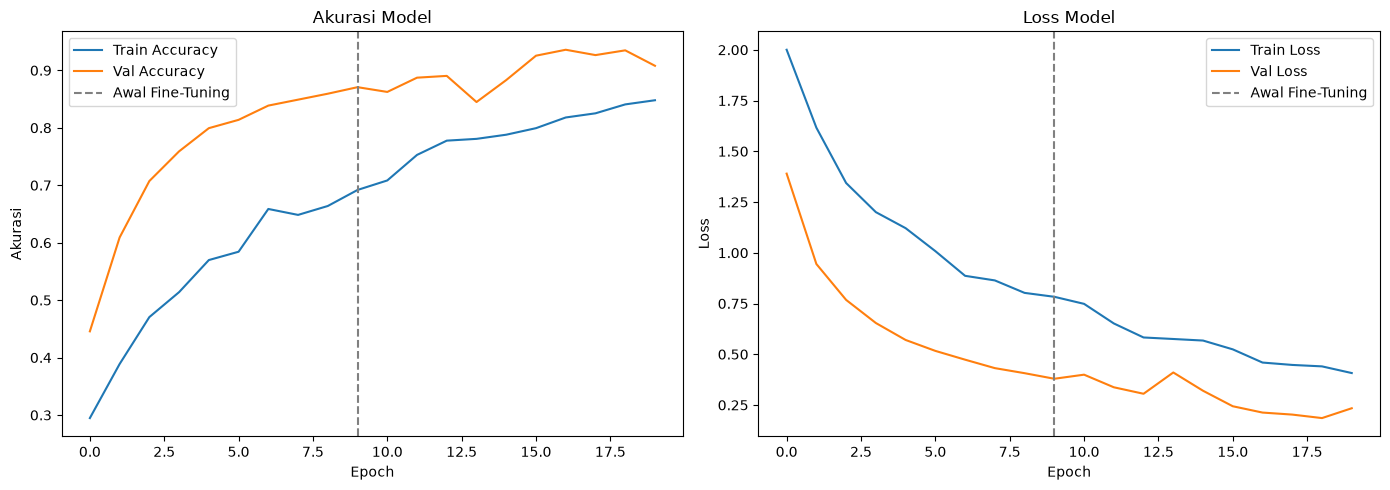

In [15]:
def gabungkan_history(h1, h2):
    combined = {}
    for key in h1.history.keys():
        combined[key] = h1.history[key] + h2.history[key]
    return combined

history = gabungkan_history(history_stage1, history_stage2)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history["accuracy"], label="Train Accuracy")
plt.plot(history["val_accuracy"], label="Val Accuracy")
plt.axvline(x=len(history_stage1.history["accuracy"]) - 1, color="gray", linestyle="--", label="Awal Fine-Tuning")
plt.title("Akurasi Model")
plt.xlabel("Epoch")
plt.ylabel("Akurasi")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.axvline(x=len(history_stage1.history["loss"]) - 1, color="gray", linestyle="--", label="Awal Fine-Tuning")
plt.title("Loss Model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


## 8. Evaluasi Model pada Data Testing

In [16]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")


31/31 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.9349 - loss: 0.1855
Test Loss     : 0.1855
Test Accuracy : 0.9349


### Confusion Matrix & Classification Report

31/31 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step
Classification Report:

              precision    recall  f1-score   support

       buaya       0.91      0.92      0.92       237
       kadal       0.97      0.88      0.92       232
   kura_kura       0.89      0.96      0.93       251
        ular       0.98      0.98      0.98       247

    accuracy                           0.93       967
   macro avg       0.94      0.93      0.93       967
weighted avg       0.94      0.93      0.93       967



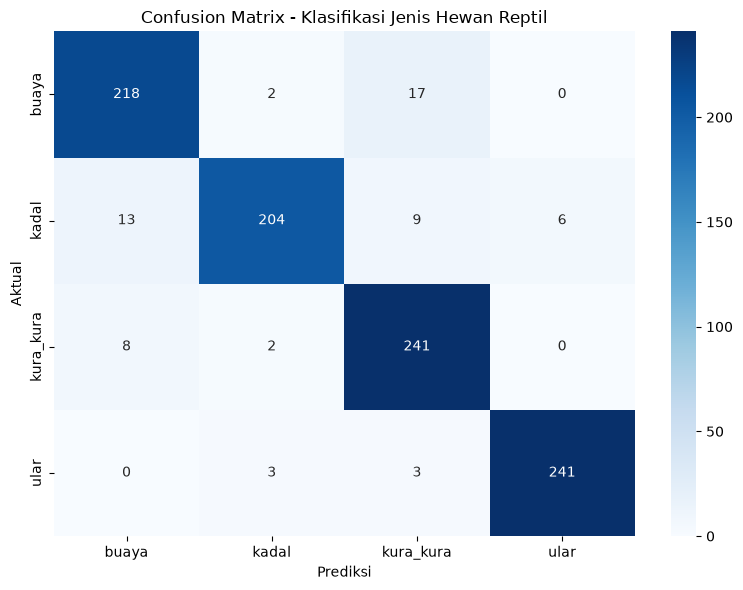

In [17]:
# Prediksi pada data test
test_generator.reset()
y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_generator.classes

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix - Klasifikasi Jenis Hewan Reptil")
plt.tight_layout()
plt.show()


## 9. Visualisasi Contoh Hasil Prediksi

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


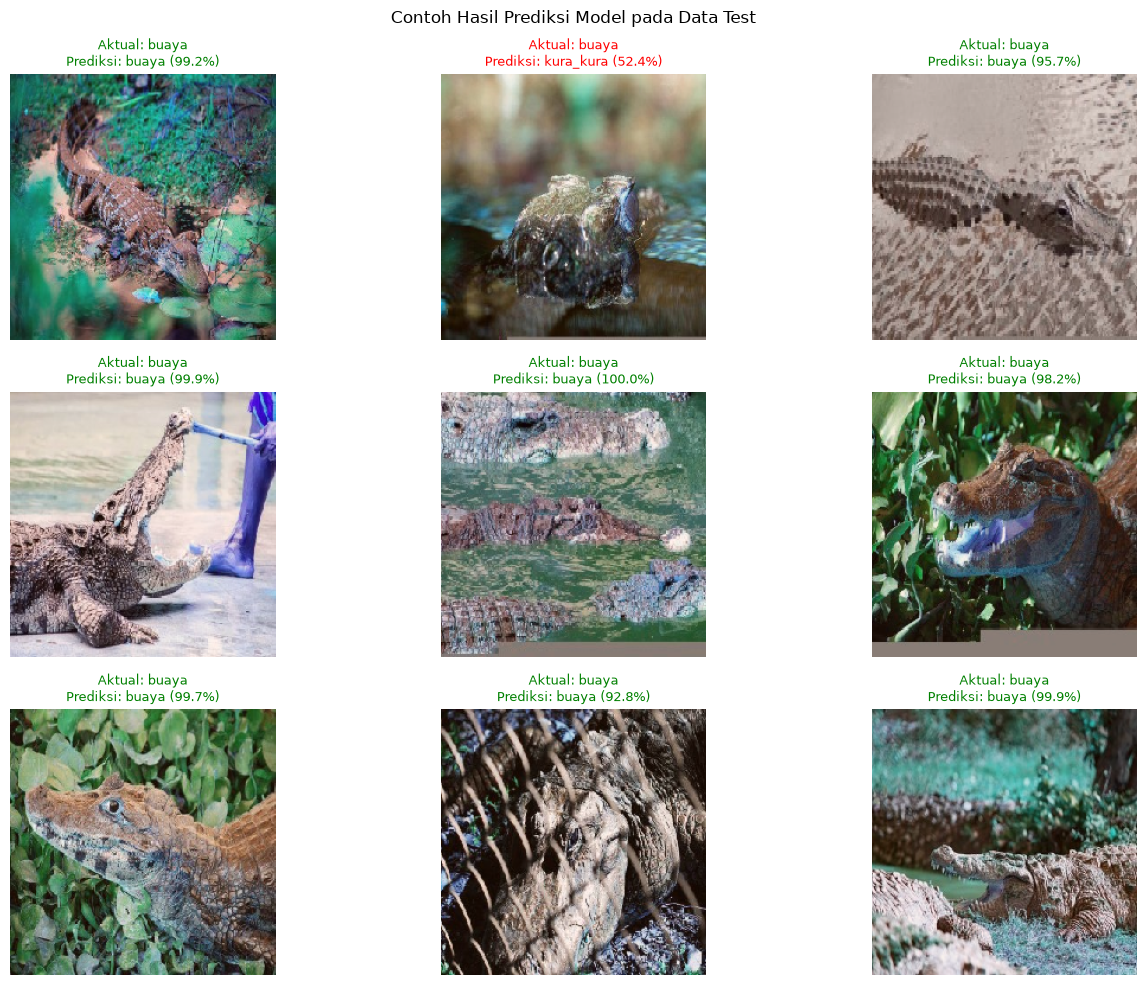

In [18]:
test_generator.reset()
images, labels = next(test_generator)
preds = model.predict(images)

plt.figure(figsize=(14, 10))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    img_display = images[i] - images[i].min()
    img_display = img_display / (img_display.max() + 1e-8)
    plt.imshow(img_display)

    true_label = class_names[np.argmax(labels[i])]
    pred_label = class_names[np.argmax(preds[i])]
    confidence = np.max(preds[i]) * 100

    color = "green" if true_label == pred_label else "red"
    plt.title(f"Aktual: {true_label}\nPrediksi: {pred_label} ({confidence:.1f}%)", color=color, fontsize=9)
    plt.axis("off")

plt.suptitle("Contoh Hasil Prediksi Model pada Data Test")
plt.tight_layout()
plt.show()


## 10. Menyimpan Model Final

In [19]:
model.save("model_vgg16_klasifikasi_reptil.h5")
print("Model berhasil disimpan sebagai 'model_vgg16_klasifikasi_reptil.h5'")


Model berhasil disimpan sebagai 'model_vgg16_klasifikasi_reptil.h5'
